In [1]:
# %%
# =============================================================================
# Célula 1: Imports e Configurações Globais
# =============================================================================
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import traceback
import glob # Para encontrar arquivos de log

# --- Imports da Biblioteca ---
try:
    from activetextclassification.data_preparation import load_and_prepare_data
    from activetextclassification.models import get_model # BaseTextClassifier, BaseFeatureClassifier não são mais usados diretamente aqui
    from activetextclassification.embeddings import get_embedder # BaseEmbedder
    from activetextclassification.optimization.genetic_l0_optimizerv2 import GeneticL0Optimizer
    from activetextclassification.utils import preprocess_label
    # --- NOVO IMPORT DE VISUALIZAÇÃO ---
    from activetextclassification.visualization.ag_plots import (
        plot_ag_convergence,
        plot_ag_population_evolution_boxplots,
        plot_ag_time_stats
    )
    print("Módulos da biblioteca activetextclassification importados.")
except Exception as e: 
    print(f"ERRO ao importar biblioteca: {e}") 
    raise e

# --- Autoreload ---
try: 
    %load_ext autoreload; 
    %autoreload 2; 
    print("Autoreload ativado.")
except Exception: pass

# --- Parâmetros do Experimento de Otimização ---
# <<< MUDE AQUI CONFORME NECESSÁRIO >>>
DATA_FILE = r'../data/dataset.csv'
TEXT_COLUMN = 'nm_item'
LABEL_COLUMN = 'nm_product'
MIN_SAMPLES_PREPROC = 5
RARE_LABEL_PREPROC = "_RARE_"
CLASSIFIER_CONFIG_AG = {
    'type': 'PVBin',
    'params': {'method':'binary', 'query':'binary', 'norm':None, 'query_norm':None, 'ngram_range': [1,2]}
}
GLOBAL_EMBEDDER_CONFIG_AG = None
L0_SIZE_TO_OPTIMIZE = 2500 # Teste com tamanho pequeno
POPULATION_SIZE_AG = 20   # População pequena para teste
N_GENERATIONS_AG = 100    # Poucas gerações para teste
CROSSOVER_RATE_AG = 0.8
MUTATION_RATE_AG = 0.2
MUTATION_STRENGTH_AG = 250 # Mutar 1 gene
ELITISM_RATE_AG = 0.05
TOURNAMENT_SIZE_AG = 3
LOG_DETAILED_FITNESS_AG = True # Ativar log detalhado

# Nomes base para arquivos de saída (serão sufixados)
OPTIMIZATION_DIR = f"ag_optimization_results_L0_{L0_SIZE_TO_OPTIMIZE}" # Diretório para organizar
os.makedirs(OPTIMIZATION_DIR, exist_ok=True) # Criar diretório

OPTIMIZATION_HISTORY_BASE_FILE = os.path.join(OPTIMIZATION_DIR, f"ag_history")
BEST_L0_BASE_FILE = os.path.join(OPTIMIZATION_DIR, f"ag_best_l0")
DETAILED_FITNESS_LOG_BASE_FILE = os.path.join(OPTIMIZATION_DIR, f"ag_detailed_fitness")
# <<< FIM MUDE AQUI >>>

print(f"Experimento de Otimização de L0 com AG") # ... (outros prints de config)
print(f"Resultados serão salvos em: {os.path.abspath(OPTIMIZATION_DIR)}")

#

Módulos da biblioteca activetextclassification importados.
Experimento de Otimização de L0 com AG
Resultados serão salvos em: d:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\examples\ag_optimization_results_L0_2500


In [2]:
# =============================================================================
# Célula 2: Carregar Dados e Preparar Embedder Global (se necessário)
# =============================================================================
# ... (Código da Célula 2 como na sua última versão, carregando df_full_ag,
#      all_possible_labels_ag, e preparando embedder_instance_ag se necessário) ...
print("\n--- Carregando e Preparando Dataset Completo para AG ---")
df_full_ag = None; all_possible_labels_ag = []; embedder_instance_ag = None
try:
    _, _, _, _, all_possible_labels_ag = load_and_prepare_data(file_path=DATA_FILE, text_column=TEXT_COLUMN, label_column=LABEL_COLUMN,min_samples_per_class=MIN_SAMPLES_PREPROC, rare_group_label=RARE_LABEL_PREPROC,population_size=0.99)
    if not all_possible_labels_ag: raise ValueError("Labels não carregados.")
    file_ext_ag = os.path.splitext(DATA_FILE)[1].lower()
    if file_ext_ag == '.csv': df_full_ag = pd.read_csv(DATA_FILE)
    elif file_ext_ag in ['.xlsx', '.xls']: df_full_ag = pd.read_excel(DATA_FILE)
    df_full_ag.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN], inplace=True)
    df_full_ag[LABEL_COLUMN] = df_full_ag[LABEL_COLUMN].apply(preprocess_label).astype(str)
    if MIN_SAMPLES_PREPROC > 1:
        counts = df_full_ag[LABEL_COLUMN].value_counts(); rare = counts[counts < MIN_SAMPLES_PREPROC].index.tolist()
        if rare: df_full_ag[LABEL_COLUMN] = df_full_ag[LABEL_COLUMN].replace(rare, RARE_LABEL_PREPROC)
    df_full_ag = df_full_ag[df_full_ag[LABEL_COLUMN].isin(all_possible_labels_ag)].copy().reset_index(drop=True)
    if df_full_ag.empty or L0_SIZE_TO_OPTIMIZE > len(df_full_ag): raise ValueError("Dataset AG inválido ou L0 muito grande.")
    clf_type_ag = CLASSIFIER_CONFIG_AG.get('type')
    if clf_type_ag in ['GNB', 'LSVC', 'LR', 'SGD'] and GLOBAL_EMBEDDER_CONFIG_AG:
        embedder_instance_ag = get_embedder(GLOBAL_EMBEDDER_CONFIG_AG)
        embedder_instance_ag.fit(df_full_ag[TEXT_COLUMN].tolist(), df_full_ag[LABEL_COLUMN].tolist())
    elif clf_type_ag in ['GNB', 'LSVC', 'LR', 'SGD'] and not GLOBAL_EMBEDDER_CONFIG_AG: raise ValueError("Embedder config ausente.")
    print(f"Dataset AG preparado: {len(df_full_ag)} amostras.")
except Exception as e: print(f"ERRO dados AG: {e}"); raise SystemExit("Falha dados AG.")





--- Carregando e Preparando Dataset Completo para AG ---
--- Iniciando Preparação de Dados ---
Carregando dados de: ../data/dataset.csv
Shape inicial: (250365, 2)
Shape após remover NaNs: (250365, 2) (0 linhas removidas)
Pré-processando rótulos...
Verificando classes com menos de 5 amostras...
Agrupando 174 classes raras em '_RARE_': ['soquete', 'jabuticaba', 'jogo de carta', 'farinha sem gluten', 'escada', 'maria mole', 'impressora', 'analgesico veterinario', 'estojo', 'quadro']...
Distribuição de classes após agrupamento:
nm_product
biscoito                                 14292
iogurte                                   7520
chocolate                                 6732
padaria e confeitaria industrializado     6046
aperitivo                                 5186
Name: count, dtype: int64
Mapeamento de rótulos finalizado: 622 classes (incluindo '_RARE_' se criado).
Dividindo em População (P = 99%) e Pool (U)...
Tamanho População P: 247861
Tamanho Pool U inicial: 2504
--- Preparação 

In [3]:
# %%
# =============================================================================
# Célula 3: Função para Executar e Salvar Otimização (com checagem de existência)
# =============================================================================

def run_and_save_optimization_with_resume(
    df_full, optimization_goal, fitness_metric_to_optimize, seed_offset=0, force_rerun=False
):
    """
    Executa o AG, salva resultados, e pula se o arquivo de histórico já existir (a menos que force_rerun).
    """
    goal_suffix = f"_{fitness_metric_to_optimize.split('_')[0].upper()}_{optimization_goal.upper()}"
    file_hist_check = f"{OPTIMIZATION_HISTORY_BASE_FILE}{goal_suffix}.xlsx"
    file_best_l0_check = f"{BEST_L0_BASE_FILE}{goal_suffix}.csv"
    detailed_log_check = f"{DETAILED_FITNESS_LOG_BASE_FILE}{fitness_metric_to_optimize.split('_')[0].upper()}_{optimization_goal.upper()}.csv"

    # --- LÓGICA DE "NÃO REFAZER" ---
    if os.path.exists(file_hist_check) and os.path.exists(file_best_l0_check) and not force_rerun:
        print(f"\n{'='*10} Otimização para {goal_suffix} JÁ EXISTE. Pulando. {'='*10}")
        print(f" - Histórico: {file_hist_check}")
        print(f" - Melhor L0: {file_best_l0_check}")
        # Tentar carregar resultados existentes para retorno
        try:
            history_df = pd.read_excel(file_hist_check)
            # Para best_l0_indices e best_actual_perf, precisaríamos de uma forma de recuperá-los
            # do arquivo best_l0 ou de um log de sumário. Por simplicidade, retornamos None se pulado.
            # Ou, se o CSV do melhor L0 tem a performance, podemos lê-la.
            best_l0_df_saved = pd.read_csv(file_best_l0_check)
            best_perf_saved = best_l0_df_saved['metric_value'].iloc[0] if not best_l0_df_saved.empty else np.nan
            # Índices não são diretamente salvos, apenas o conteúdo.
            # Poderíamos salvar os índices no CSV do melhor L0 se quisermos reconstruir.
            # Por ora, retornaremos None para índices se pulado.
            return None, best_perf_saved, history_df
        except Exception as e_load:
            print(f"AVISO: Falha ao carregar resultados existentes para {goal_suffix}: {e_load}")
            return None, np.nan, pd.DataFrame()
    # --- FIM "NÃO REFAZER" ---


    print(f"\n{'='*15} Iniciando Otimização (L0Tam: {L0_SIZE_TO_OPTIMIZE}, Obj: {optimization_goal.upper()}, Métrica: {fitness_metric_to_optimize}) {'='*15}")

    ag_optimizer = GeneticL0Optimizer(
        df_full=df_full, text_column=TEXT_COLUMN, label_column=LABEL_COLUMN,
        classifier_config=CLASSIFIER_CONFIG_AG, initial_l0_size=L0_SIZE_TO_OPTIMIZE,
        all_possible_labels=all_possible_labels_ag, population_size=POPULATION_SIZE_AG,
        n_generations=N_GENERATIONS_AG, crossover_rate=CROSSOVER_RATE_AG,
        mutation_rate=MUTATION_RATE_AG, mutation_strength=MUTATION_STRENGTH_AG,
        elitism_rate=ELITISM_RATE_AG, fitness_metric=fitness_metric_to_optimize,
        optimization_goal=optimization_goal, tournament_size=TOURNAMENT_SIZE_AG,
        random_seed=42 + seed_offset, embedder=embedder_instance_ag,
        log_detailed_fitness=LOG_DETAILED_FITNESS_AG, # Usar config global
        detailed_log_file=detailed_log_check, # Passar o nome do arquivo correto
        n_jobs=-1 # utilizar todos os núcleos disponíveis
    )

    best_l0_indices, best_actual_perf, history_df = ag_optimizer.run_optimization()

    # Salvar Histórico
    if history_df is not None and not history_df.empty:
        print(f"Salvando histórico ({goal_suffix}) em: {file_hist_check}")
        try: history_df.to_excel(file_hist_check, index=False)
        except Exception as e: print(f"Erro salvar histórico AG ({goal_suffix}): {e}")
    else: print(f"Nenhum histórico de otimização para salvar ({goal_suffix}).")

    # Salvar Melhor/Pior L0
    if best_l0_indices is not None and len(best_l0_indices) > 0:
        print(f"Salvando L0 (Obj: {optimization_goal}, Perf: {best_actual_perf:.4f}) em: {file_best_l0_check}")
        best_l0_df = df_full.iloc[best_l0_indices][[TEXT_COLUMN, LABEL_COLUMN]].copy()
        best_l0_df['metric_value'] = best_actual_perf
        best_l0_df['metric_type'] = fitness_metric_to_optimize
        best_l0_df['optimization_goal'] = optimization_goal
        # best_l0_df['l0_indices_str'] = ",".join(map(str, best_l0_indices)) # Salvar os índices também
        try: best_l0_df.to_csv(file_best_l0_check, index=False, encoding='utf-8-sig')
        except Exception as e: print(f"Erro salvar L0 ({goal_suffix}): {e}")
    else: print(f"Nenhum L0 encontrado (Obj: {optimization_goal}, {goal_suffix}).")

    return best_l0_indices, best_actual_perf, history_df



In [4]:
# %%
# =============================================================================
# Célula 4: Executar Otimizações
# =============================================================================
FORCE_RERUN_OPTIMIZATIONS = False # Mude para True para re-rodar tudo
optimization_results = {}

if df_full_ag is not None and not df_full_ag.empty:
    # --- Otimizar para ACURÁCIA ---
    res_acc_max = run_and_save_optimization_with_resume(df_full_ag, 'maximize', 'accuracy_on_full', 0, FORCE_RERUN_OPTIMIZATIONS)
    optimization_results['ACC_MAX'] = {'indices': res_acc_max[0], 'performance': res_acc_max[1], 'history_df': res_acc_max[2]}

    res_acc_min = run_and_save_optimization_with_resume(df_full_ag, 'minimize', 'accuracy_on_full', 100, FORCE_RERUN_OPTIMIZATIONS)
    optimization_results['ACC_MIN'] = {'indices': res_acc_min[0], 'performance': res_acc_min[1], 'history_df': res_acc_min[2]}

    # --- Otimizar para F1-SCORE ---
    res_f1_max = run_and_save_optimization_with_resume(df_full_ag, 'maximize', 'f1_macro_on_full', 200, FORCE_RERUN_OPTIMIZATIONS)
    optimization_results['F1_MAX'] = {'indices': res_f1_max[0], 'performance': res_f1_max[1], 'history_df': res_f1_max[2]}

    res_f1_min = run_and_save_optimization_with_resume(df_full_ag, 'minimize', 'f1_macro_on_full', 300, FORCE_RERUN_OPTIMIZATIONS)
    optimization_results['F1_MIN'] = {'indices': res_f1_min[0], 'performance': res_f1_min[1], 'history_df': res_f1_min[2]}

    print("\n--- Todas as Otimizações Programadas Concluídas/Puladas ---")
else:
    print("ERRO: df_full_ag não está definido ou está vazio. Não é possível executar otimizações.")



=============== Iniciando Otimização (L0Tam: 2500, Obj: MAXIMIZE, Métrica: accuracy_on_full) ===============
Usando 8 processos para cálculo de fitness.
GeneticL0Optimizer inicializado.
 - População: 20, Gerações: 100, L0 Size: 2500
 - Objetivo: maximize, Métrica: accuracy_on_full
 - Log Detalhado ATIVADO em: d:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\examples\ag_optimization_results_L0_2500\ag_detailed_fitnessACCURACY_MAXIMIZE.csv

--- Iniciando Otimização Genética (Tam: 2500, Obj: maximize, Métrica: accuracy_on_full) ---
Inicializando população...


Criando População Inicial:   0%|          | 0/20 [00:00<?, ?it/s]

Gerações AG:   0%|          | 0/100 [00:00<?, ?it/s]


  Geração 1/100


Fitness Calc Gen 1 (Parallel):   0%|          | 0/20 [00:00<?, ?it/s]

...

    Acc Real Geração 98: Max=0.6584, Avg=0.6554, Min=0.6542
    F1 Real Geração  98: Max=0.2555, Avg=0.2428, Min=0.2411
    Duração Geração 98: 19.88s

  Geração 99/100


Fitness Calc Gen 99 (Parallel):   0%|          | 0/3 [00:00<?, ?it/s]

    Acc Real Geração 99: Max=0.6648, Avg=0.6561, Min=0.6553
    F1 Real Geração  99: Max=0.2533, Avg=0.2426, Min=0.2411
    Duração Geração 99: 18.63s

  Geração 100/100


Fitness Calc Gen 100 (Parallel):   0%|          | 0/2 [00:00<?, ?it/s]

    Acc Real Geração 100: Max=0.6621, Avg=0.6554, Min=0.6518
    F1 Real Geração  100: Max=0.2569, Avg=0.2424, Min=0.2411
    Duração Geração 100: 16.19s

--- Otimização Genética Concluída (3653.30 seg) ---
Melhor Performance Real Encontrada (f1_macro_on_full, Objetivo: minimize): 0.2411
Salvando histórico (_F1_MINIMIZE) em: ag_optimization_results_L0_2500\ag_history_F1_MINIMIZE.xlsx
Salvando L0 (Obj: minimize, Perf: 0.2411) em: ag_optimization_results_L0_2500\ag_best_l0_F1_MINIMIZE.csv

--- Todas as Otimizações Programadas Concluídas/Puladas ---



--- Carregando e Plotando Resultados da Otimização AG ---

--- Visualizando para: AG Maximize Acurácia ---


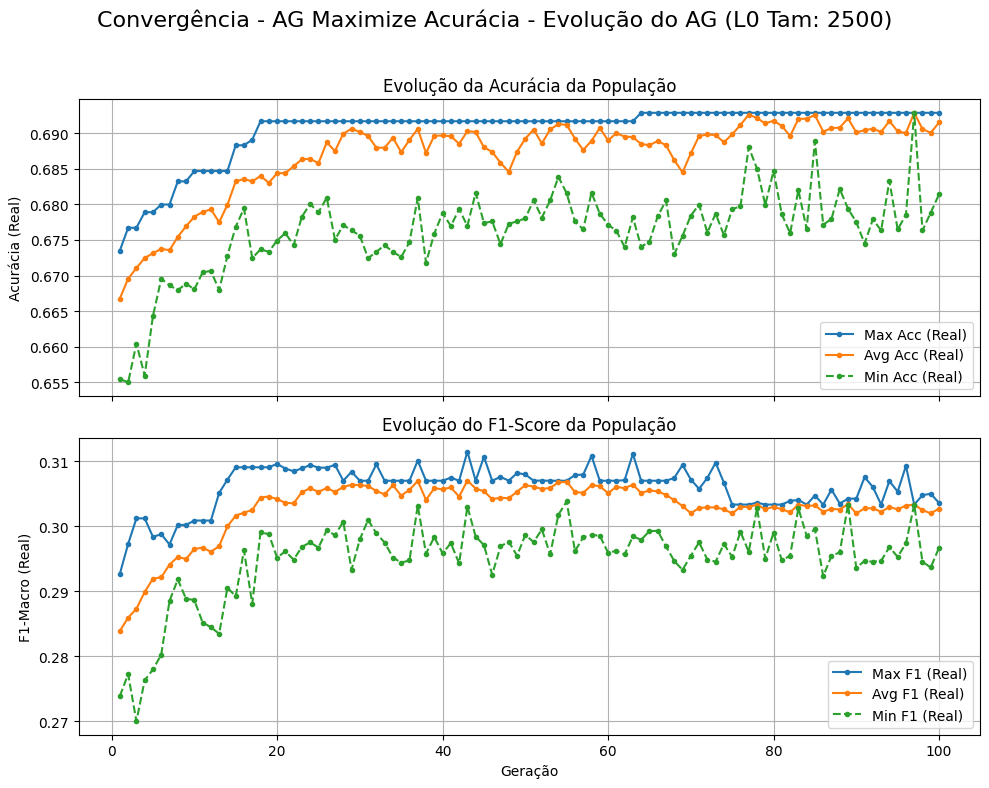

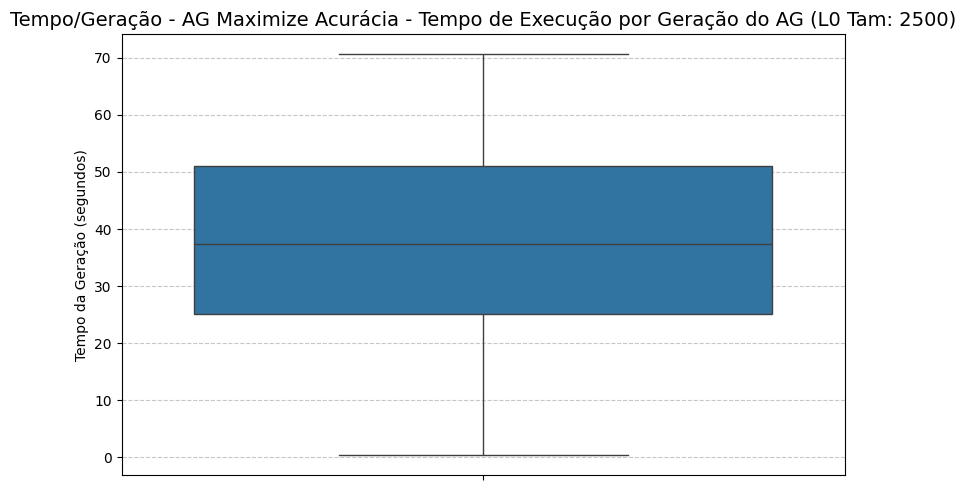

Estatísticas do Tempo por Geração (Tempo/Geração - AG Maximize Acurácia):
count    100.000000
mean      37.791155
std       15.210898
min        0.399881
25%       25.050377
50%       37.411273
75%       51.062807
max       70.587178
Name: generation_time_sec, dtype: float64


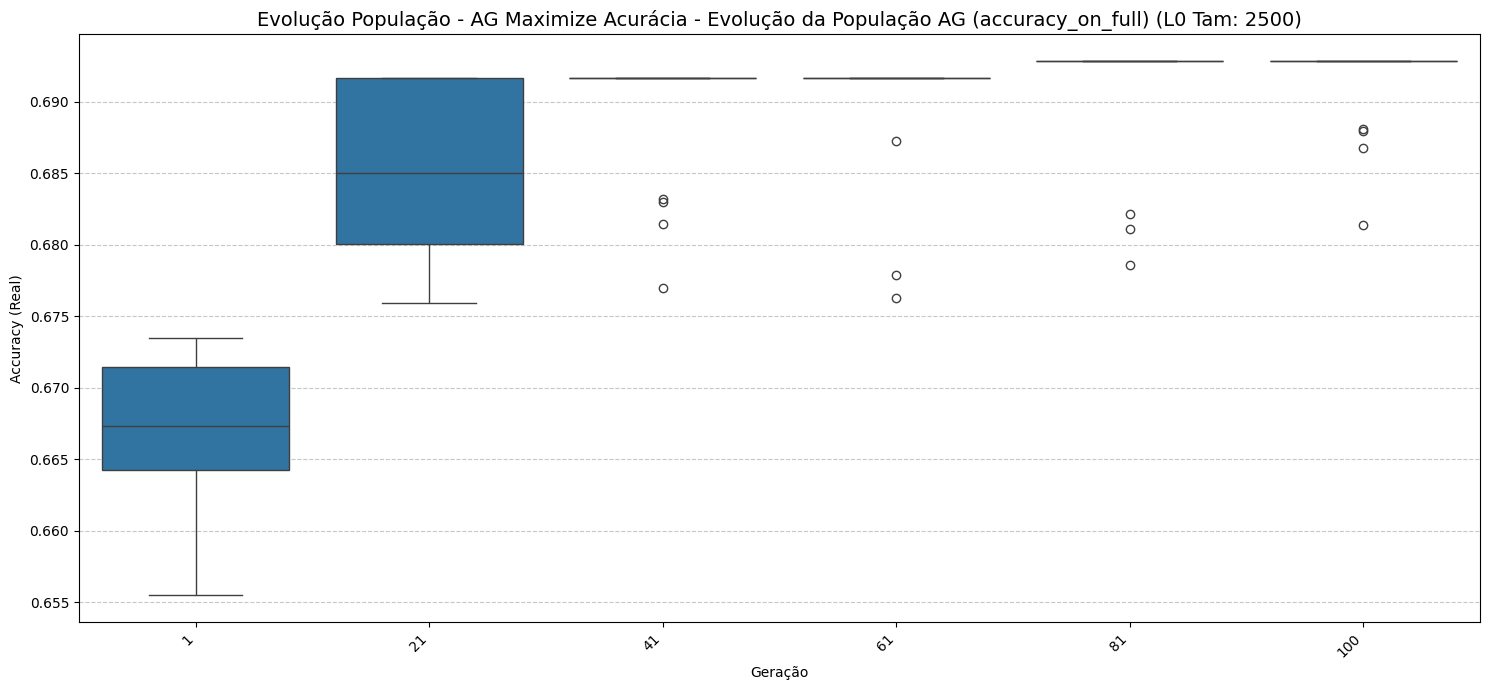


--- Visualizando para: AG Minimize Acurácia ---


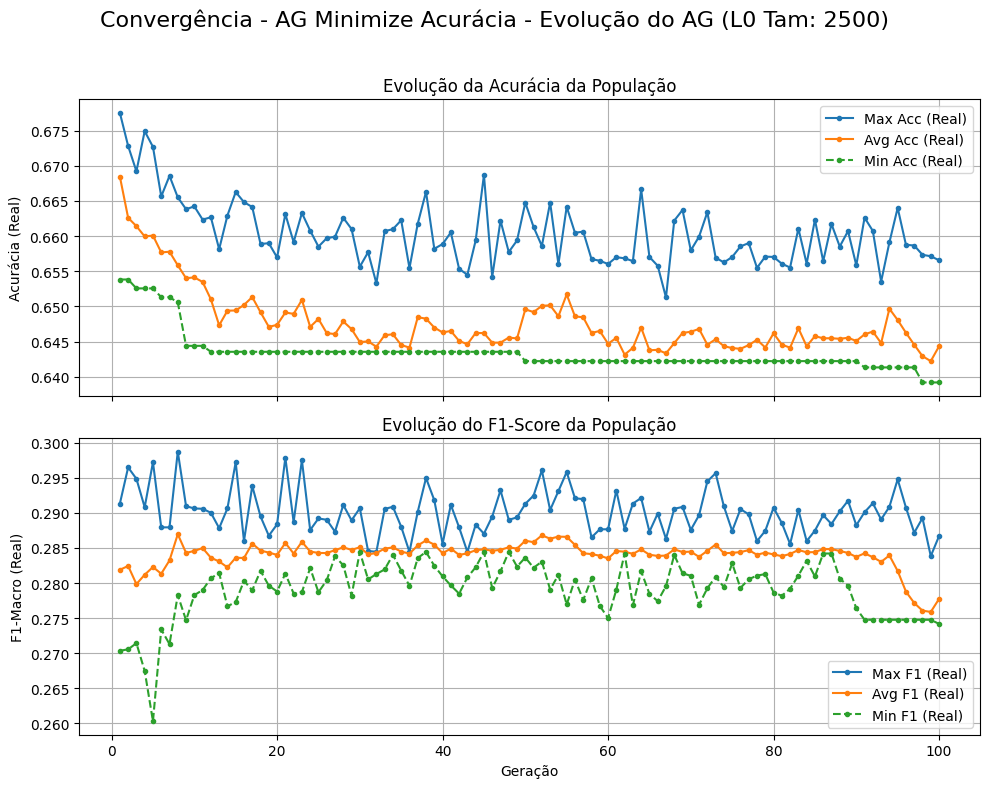

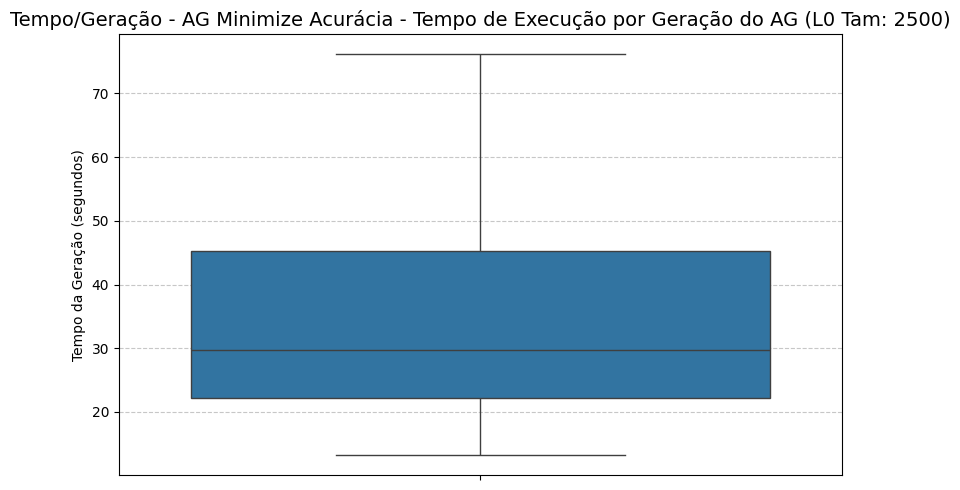

Estatísticas do Tempo por Geração (Tempo/Geração - AG Minimize Acurácia):
count    100.000000
mean      34.561238
std       14.575808
min       13.222440
25%       22.125795
50%       29.709533
75%       45.262181
max       76.141268
Name: generation_time_sec, dtype: float64


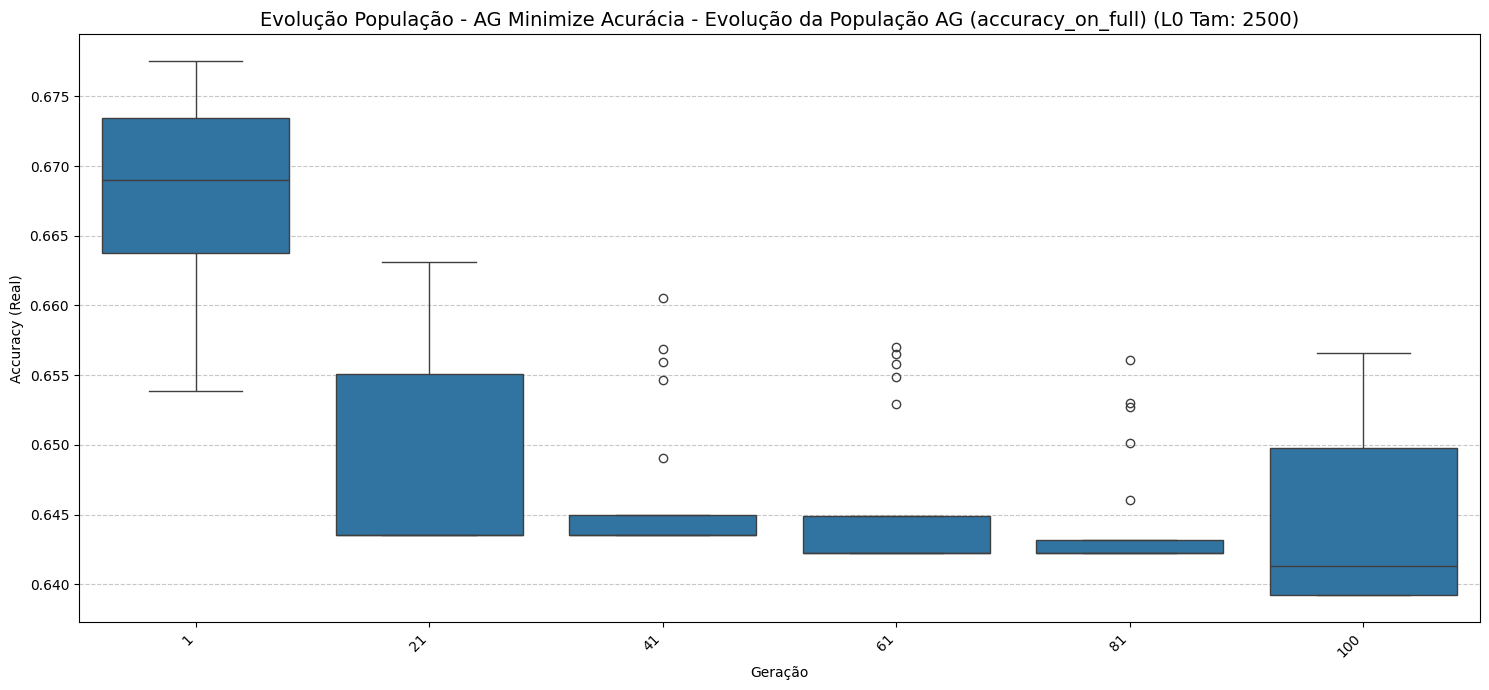


--- Visualizando para: AG Maximize F1-Macro ---


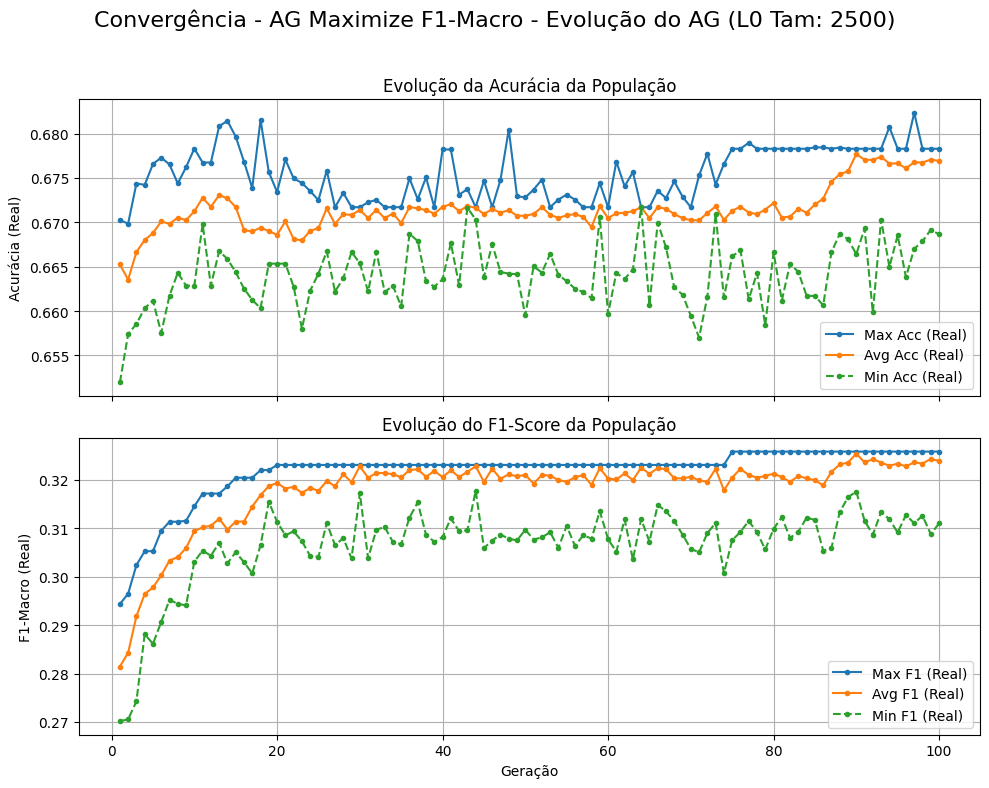

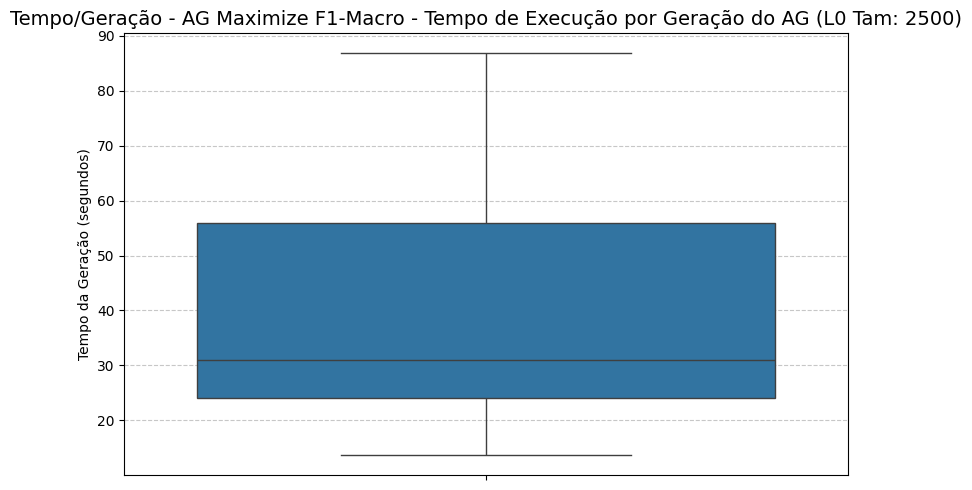

Estatísticas do Tempo por Geração (Tempo/Geração - AG Maximize F1-Macro):
count    100.000000
mean      38.281845
std       19.555738
min       13.675414
25%       24.067886
50%       31.031300
75%       55.923113
max       86.794246
Name: generation_time_sec, dtype: float64


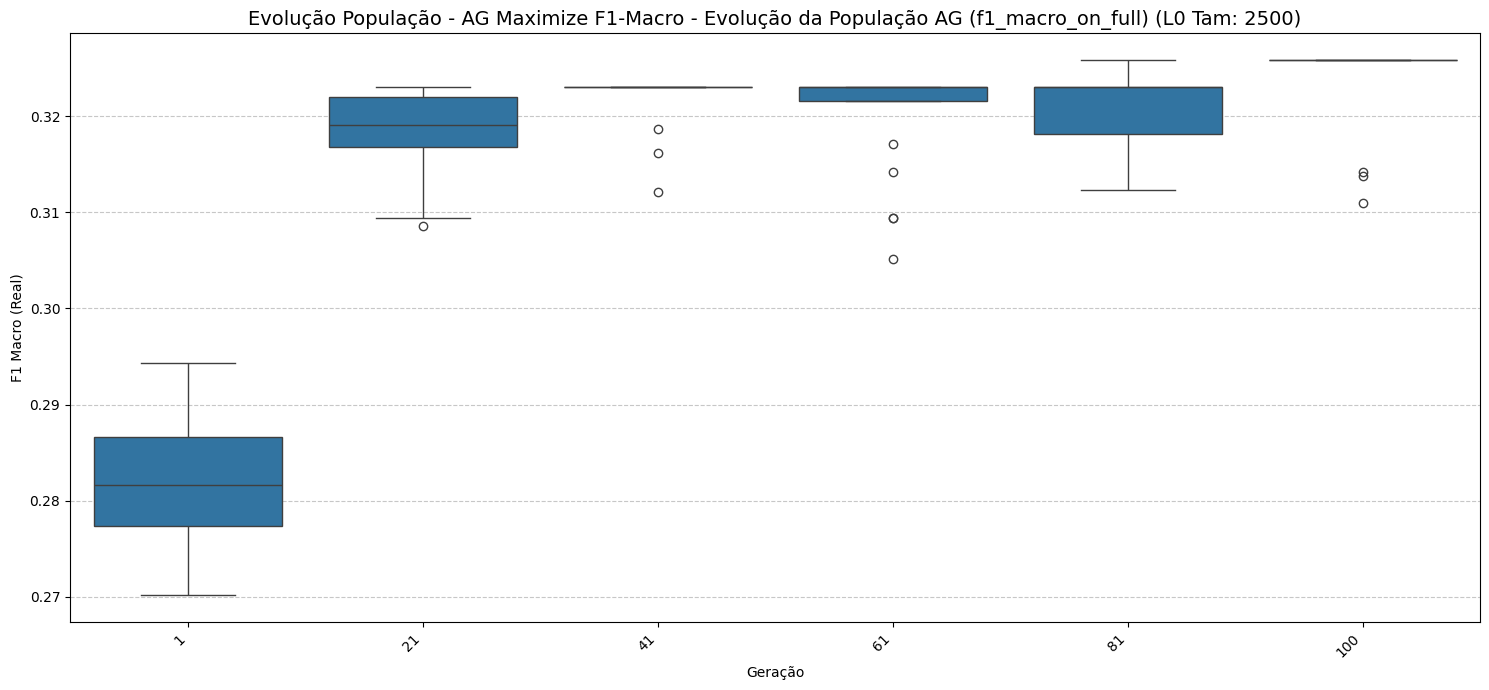


--- Visualizando para: AG Minimize F1-Macro ---


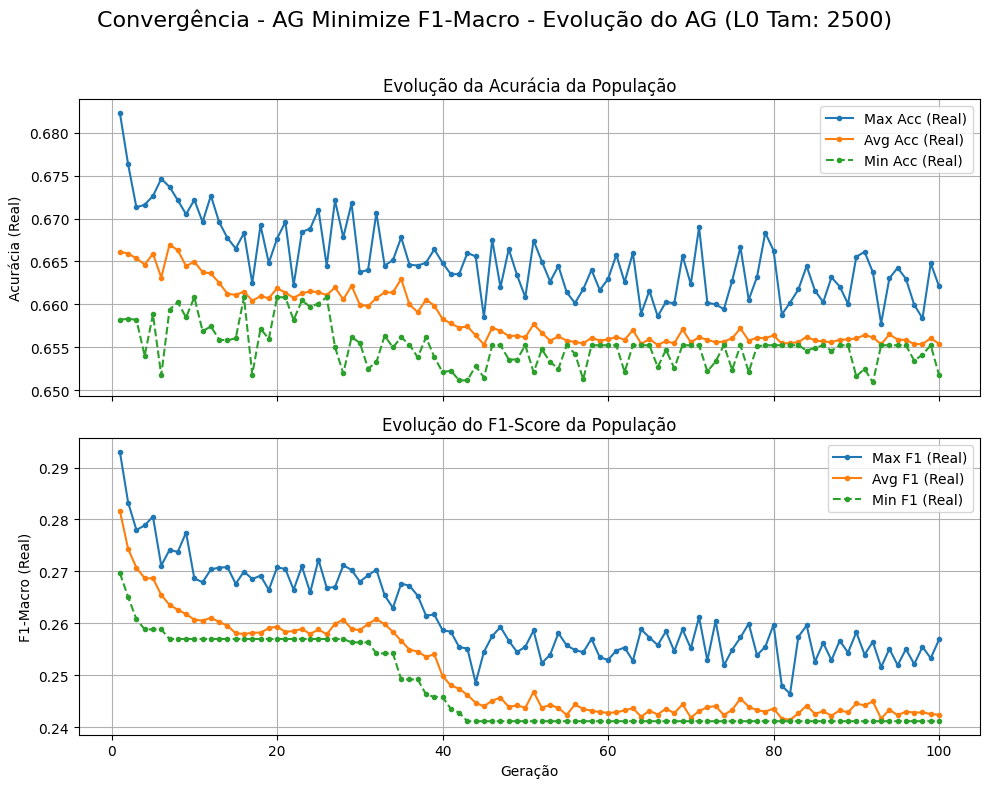

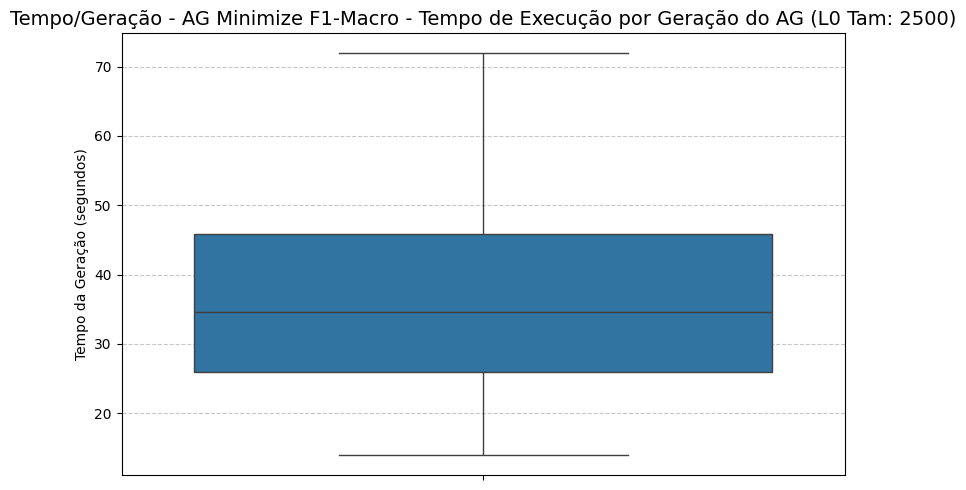

Estatísticas do Tempo por Geração (Tempo/Geração - AG Minimize F1-Macro):
count    100.000000
mean      36.432149
std       13.813786
min       13.969062
25%       25.949938
50%       34.590217
75%       45.876113
max       71.907407
Name: generation_time_sec, dtype: float64


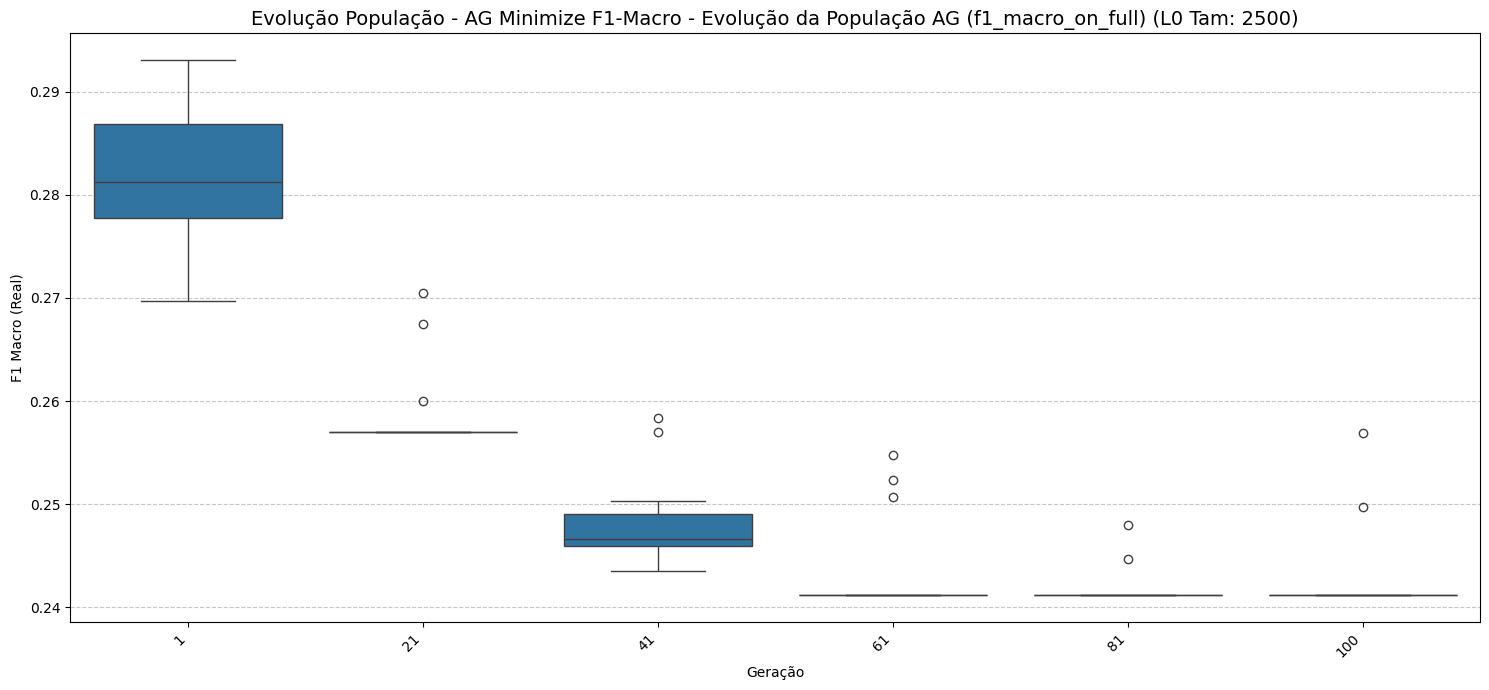

In [5]:
# %%
# =============================================================================
# Célula 5: Visualização dos Resultados da Otimização AG
# =============================================================================
print("\n--- Carregando e Plotando Resultados da Otimização AG ---")

# Loop para carregar e plotar cada resultado salvo (se não já em optimization_results)
plot_configs = [
    {'goal': 'maximize', 'metric': 'accuracy_on_full', 'key': 'ACC_MAX', 'title_metric': 'Acurácia'},
    {'goal': 'minimize', 'metric': 'accuracy_on_full', 'key': 'ACC_MIN', 'title_metric': 'Acurácia'},
    {'goal': 'maximize', 'metric': 'f1_macro_on_full', 'key': 'F1_MAX', 'title_metric': 'F1-Macro'},
    {'goal': 'minimize', 'metric': 'f1_macro_on_full', 'key': 'F1_MIN', 'title_metric': 'F1-Macro'}
]

for p_config in plot_configs:
    goal_suffix = f"_{p_config['metric'].split('_')[0].upper()}_{p_config['goal'].upper()}"
    history_file = f"{OPTIMIZATION_HISTORY_BASE_FILE}{goal_suffix}.xlsx"
    detailed_log_file = f"{DETAILED_FITNESS_LOG_BASE_FILE}{p_config['metric'].split('_')[0].upper()}_{p_config['goal'].upper()}.csv"
    title_prefix = f"AG {p_config['goal'].capitalize()} {p_config['title_metric']}"

    print(f"\n--- Visualizando para: {title_prefix} ---")

    # Carregar histórico se não estiver já no dict optimization_results ou se estiver vazio
    history_df_plot = optimization_results.get(p_config['key'], {}).get('history_df')
    if history_df_plot is None or history_df_plot.empty:
        if os.path.exists(history_file):
            try: history_df_plot = pd.read_excel(history_file)
            except Exception as e: print(f"  Erro ao carregar {history_file}: {e}")
        else: print(f"  Arquivo de histórico {history_file} não encontrado.")

    # Plotar convergência
    if history_df_plot is not None and not history_df_plot.empty:
        plot_ag_convergence(history_df_plot, title_prefix=f"Convergência - {title_prefix}", l0_size=L0_SIZE_TO_OPTIMIZE)
        plot_ag_time_stats(history_df_plot, title_prefix=f"Tempo/Geração - {title_prefix}", l0_size=L0_SIZE_TO_OPTIMIZE)

    # Carregar e plotar boxplots da população
    if LOG_DETAILED_FITNESS_AG and os.path.exists(detailed_log_file):
        try:
            df_detailed_plot = pd.read_csv(detailed_log_file)
            # A métrica a ser plotada no boxplot é a que foi otimizada
            metric_col_for_boxplot = p_config['metric'] # 'accuracy_on_full' ou 'f1_macro_on_full'
            plot_ag_population_evolution_boxplots(
                df_detailed_plot,
                metric_to_plot=metric_col_for_boxplot,
                title_prefix=f"Evolução População - {title_prefix}",
                l0_size=L0_SIZE_TO_OPTIMIZE,
                generation_step=max(1, N_GENERATIONS_AG // 5) # Plotar ~5 boxplots
            )
        except Exception as e:
            print(f"  Erro ao carregar ou plotar log detalhado {detailed_log_file}: {e}")
    elif LOG_DETAILED_FITNESS_AG:
        print(f"  Arquivo de log detalhado {detailed_log_file} não encontrado.")